In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.load_config import load_config
from utils.load_data import load_pkl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.utils import resample

## Data loading

In [2]:
cfg = load_config()
marisma_pkl = cfg["data"]["MARISMA_PICKLE"]

In [3]:
marisma = load_pkl(marisma_pkl)

In [4]:
data, label, meta = marisma["data"], marisma["label"], marisma["meta"]

In [5]:
meta = pd.DataFrame.from_records(list(meta))

## Preprocessing

Normalize each spectrum

In [6]:
# axis=1 to work row by row
# keepdims=True keeps the dimensions needed for per-row normalization to work correctly
data_norm = (data - data.min(axis=1, keepdims=True)) / (
    data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

Reduce dimensionality (there are 6000 features)

In [48]:
my_pca = PCA().fit(data_norm)

In [49]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

In [50]:
print(cumulative_explained_var)
print(cumulative_explained_var_ratio)

[22.05654523 37.97864638 46.11430022 ... 98.57128616 98.57128616
 98.57128617]
[0.22376238 0.38529117 0.46782691 ... 1.         1.         1.        ]


Text(0, 0.5, 'Cumulative explained variance')

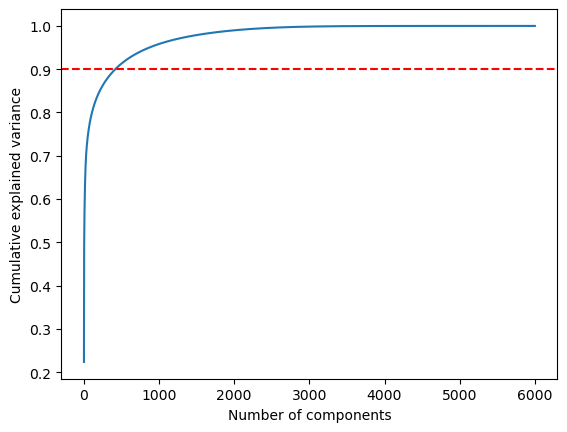

In [51]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

In [52]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.9) + 1
print(f"Number of components explaining 90% variance: {n_components}")

Number of components explaining 90% variance: 418


This indicates that 418 components are needed to account for 90% of the variance in our dataset. However, this is still a lot for t-SNE, so it is recommended to try and reduce the number of components

In [55]:
possible_dims = [30, 50, 100]
for dim in possible_dims:
    pca = PCA(n_components=dim).fit(data_norm)
    print(f"Explained variance with {dim} components: {np.sum(pca.explained_variance_ratio_)}")

Explained variance with 30 components: 0.7019925622343979
Explained variance with 50 components: 0.7423888490086569
Explained variance with 100 components: 0.7941803822587071


In [7]:
data_norm_pca = PCA(n_components=50).fit_transform(data_norm)

## t-SNE Embedding

In [ ]:
perplexity_values = [5, 10, 30, 50, 100, 200]
results = []

for perplexity in perplexity_values:
    # Fit the t-SNE
    my_tsne = TSNE(n_components=2, perplexity=perplexity)
    data_tsne = my_tsne.fit_transform(data_norm_pca)

    # Compute trustworthiness
    # mide si los puntos que eran vecinos en el espacio original siguen siéndolo en el embedding
    tw = trustworthiness(data_norm_pca, data_tsne, n_neighbors=perplexity)
    results.append((perplexity, tw))
    print(f"Perplexity={perplexity}, Trustworthiness={tw}")

In [78]:
perp = 70
my_tsne = TSNE(n_components=2, perplexity=perp)
data_tsne = my_tsne.fit_transform(data_norm_pca)

In [79]:
perp=70

In [80]:
n_samples = 10000
X_pca_sub, X_tsne_sub, y_sub = resample(
    data_norm_pca, data_tsne, label, n_samples=n_samples, stratify=label)

tw = trustworthiness(X_pca_sub, X_tsne_sub, n_neighbors=perp)
print(f"Trustworthiness (10k stratified sample): {tw:.3f}")

Trustworthiness (10k stratified sample): 0.984


## Visualization

Map labels to numbers

In [81]:
# Identify unique labels
unique_labels = np.unique(label)
print(unique_labels)

['Enterobacter_cloacae_complex' 'Enterococcus_Faecium' 'Escherichia_Coli'
 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa' 'Staphylococcus_Aureus']


In [82]:
# Assign a number to each label
label_to_idx = {}
for i in range(len(unique_labels)):
    label_to_idx[str(unique_labels[i])] = i
label_to_idx

{'Enterobacter_cloacae_complex': 0,
 'Enterococcus_Faecium': 1,
 'Escherichia_Coli': 2,
 'Klebsiella_Pneumoniae': 3,
 'Pseudomonas_Aeruginosa': 4,
 'Staphylococcus_Aureus': 5}

In [83]:
# Map label dataset 
encoded_label = np.array([label_to_idx[l] for l in label])
encoded_label

array([4, 4, 4, ..., 0, 0, 0], shape=(76172,))

Visualize

In [84]:
# Create a DataFrame combining coordinates and metadata
tsne_df = pd.DataFrame({
    "x": data_tsne[:, 0],
    "y": data_tsne[:, 1],
    "species": label,
    "year": meta["year"].astype(str), 
    "study": meta["study"].astype(str)
})

In [85]:
tsne_df

,x,y,species,year,study
0,-11.160166,48.762951,Pseudomonas_Aeruginosa,2020,ac9d3149/0_C2/1
1,13.674367,83.280144,Pseudomonas_Aeruginosa,2020,840724c3/0_D7/1
2,-18.768513,88.354675,Pseudomonas_Aeruginosa,2020,840724c3/0_C5/1
3,-30.456343,74.136940,Pseudomonas_Aeruginosa,2020,5db4adbf/0_B11/1
4,-31.402489,58.032322,Pseudomonas_Aeruginosa,2020,8662f7d6/0_A4/1
...,...,...,...,...,...
76167,3.284661,6.092426,Enterobacter_cloacae_complex,2022,991f60fb/0_E3/1
76168,-8.017513,0.354739,Enterobacter_cloacae_complex,2022,1a44a359-1A/0_C12/1
76169,2.857076,-1.780269,Enterobacter_cloacae_complex,2022,57e2ec67-2/0_A5/1
76170,3.479328,-0.094008,Enterobacter_cloacae_complex,2022,6ae3dc2d-2E/0_B10/1


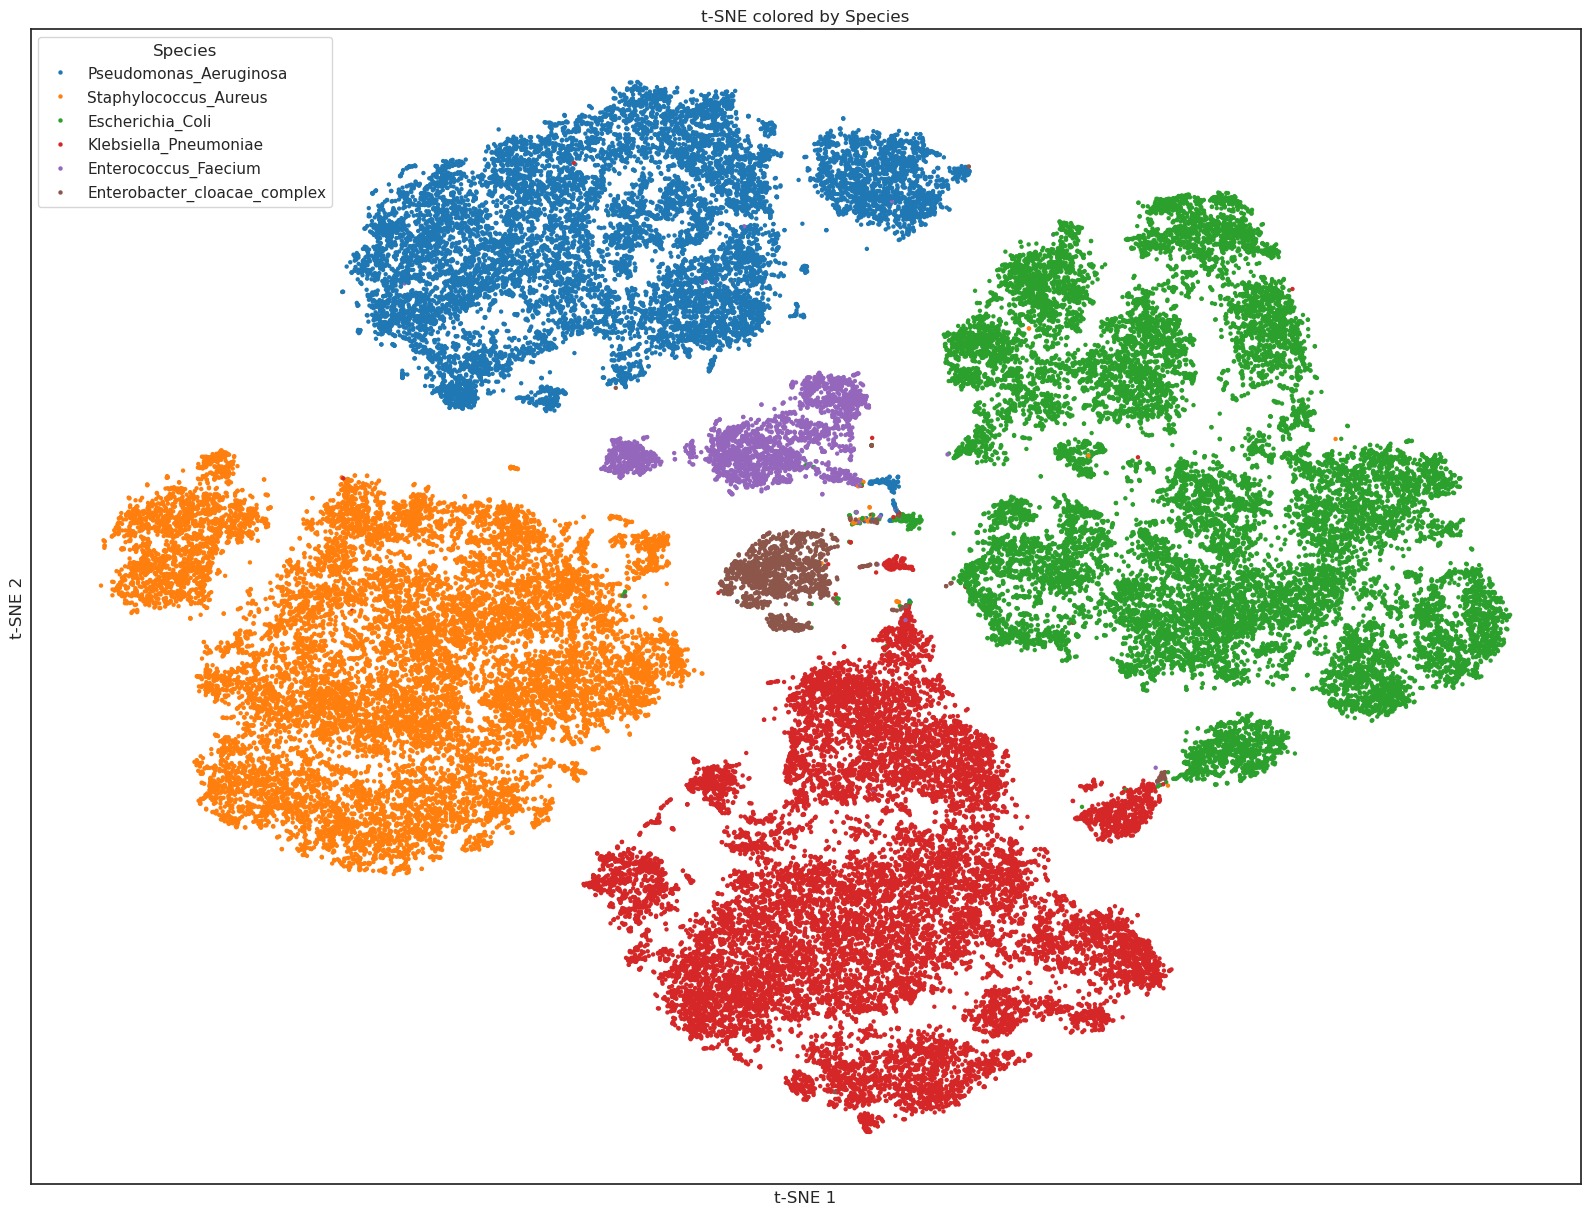

In [86]:
# t-SNE by species
fig, ax = plt.subplots(figsize=(20, 15))

sns.scatterplot(
    data=tsne_df,
    x="x", y="y",
    hue="species",
    palette=sns.color_palette("tab10", n_colors=tsne_df["species"].nunique()),
    s=10, linewidth=0, ax=ax
)

ax.set_title("t-SNE colored by Species", fontsize=12)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Species")

plt.show()

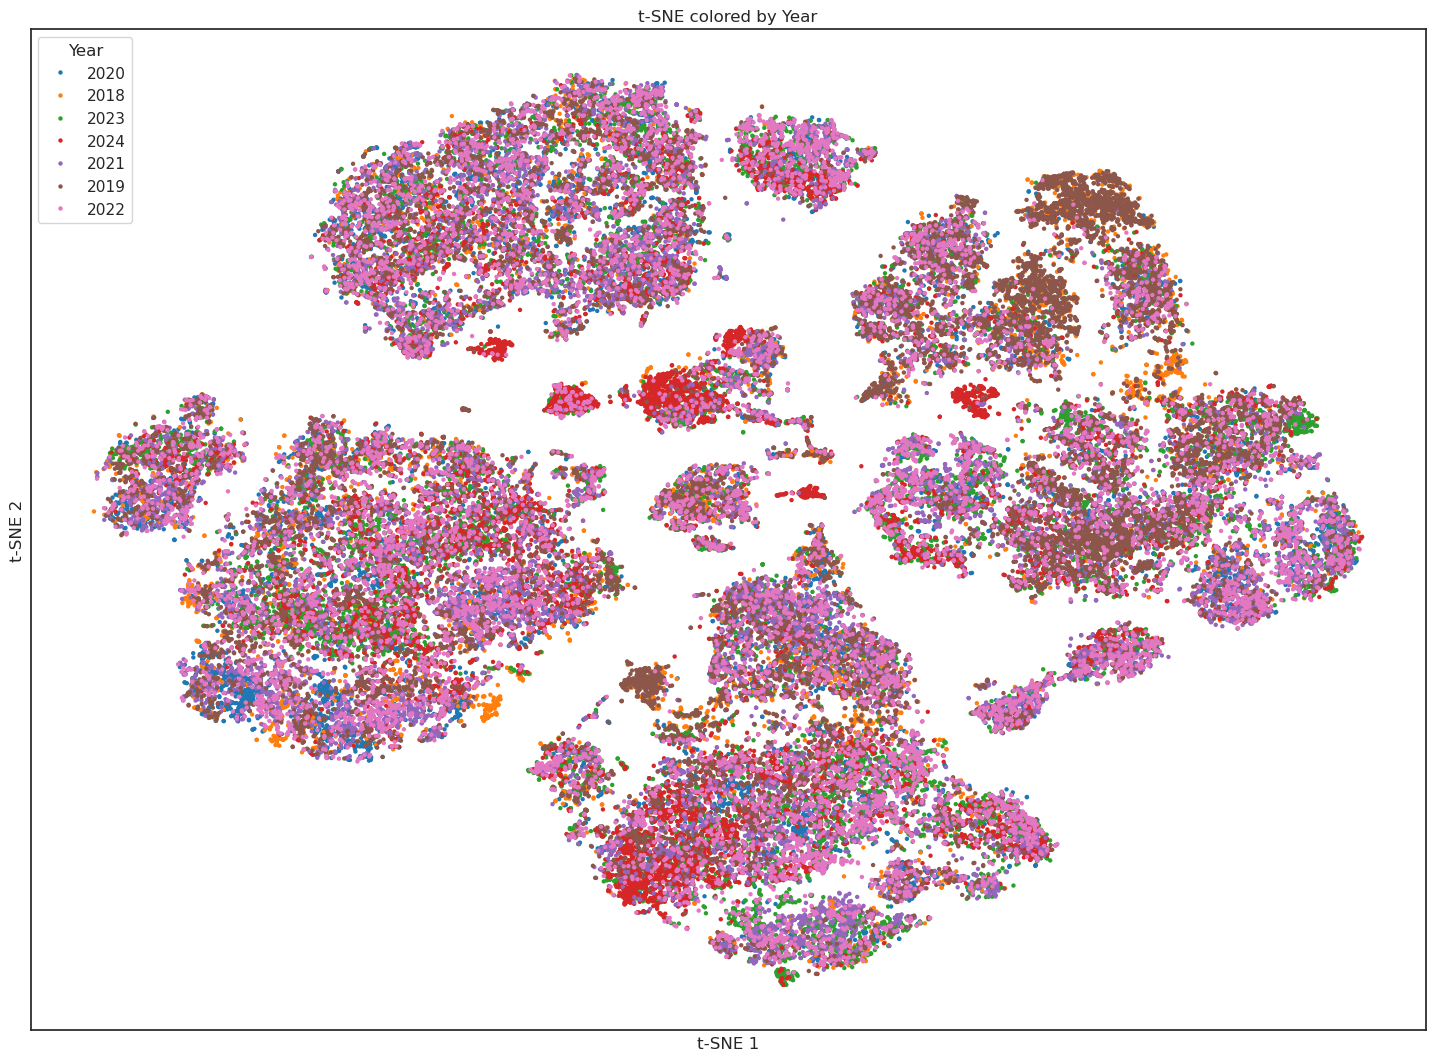

In [ ]:
# t-SNE by year (global)
fig, ax = plt.subplots(figsize=(18, 13))

sns.scatterplot(
    data=tsne_df,
    x="x", y="y",
    hue="year",
    palette=sns.color_palette("tab10", n_colors=tsne_df["year"].nunique()),
    s=10, linewidth=0, ax=ax
)

ax.set_title("t-SNE colored by Year", fontsize=12)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Year")

plt.show()


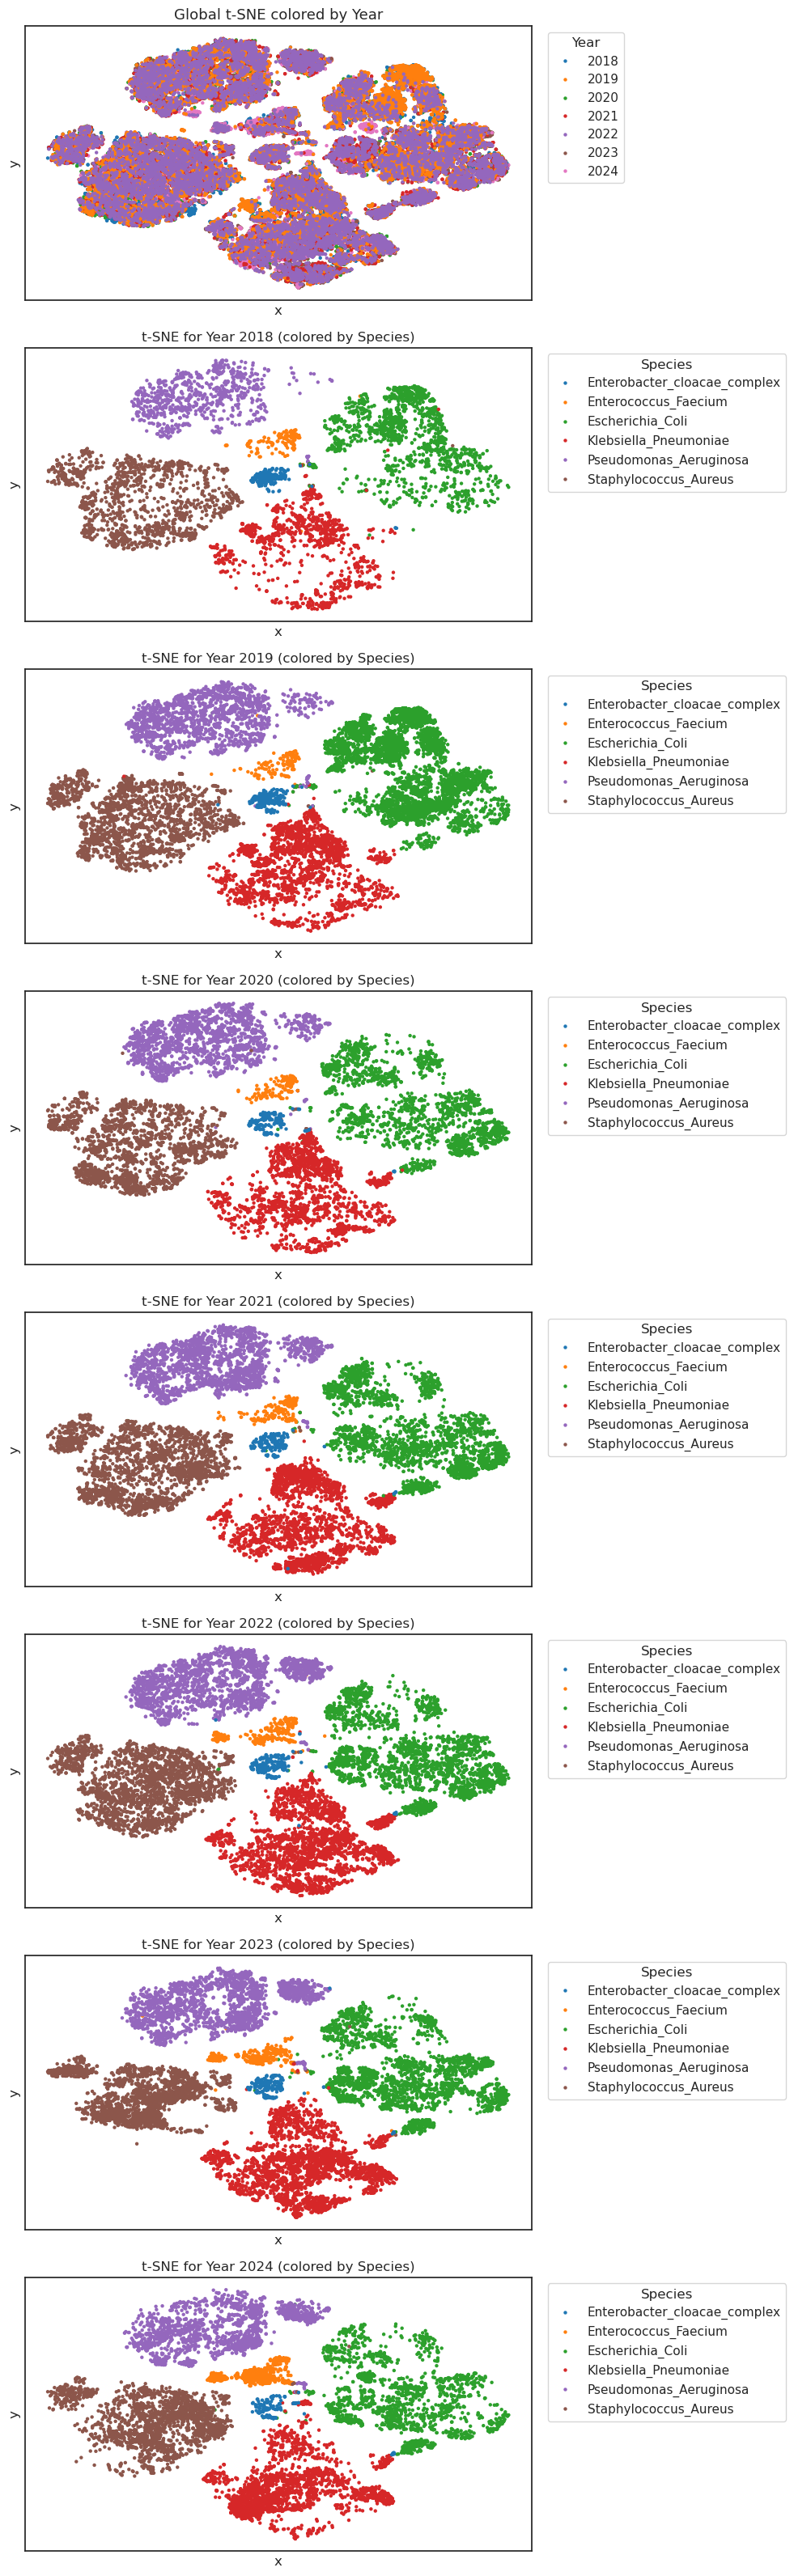

In [ ]:
years = sorted(tsne_df["year"].unique(), key=lambda x: int(x))
species_order = sorted(tsne_df["species"].unique()) 
species_palette = sns.color_palette("tab10", n_colors=len(species_order))

# Create species-color mapping
species_to_color = dict(zip(species_order, species_palette))

# Create figure
n_rows = len(years) + 1
fig, axes = plt.subplots(n_rows, 1, figsize=(10, 4 * n_rows))

# Global t-SNE by Year
sns.scatterplot(
    data=tsne_df,
    x="x", y="y",
    hue="year",
    hue_order=years,
    palette=sns.color_palette("tab10", n_colors=len(years)),
    s=10, linewidth=0, ax=axes[0]
)
axes[0].set_title("Global t-SNE colored by Year", fontsize=13)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Year")
axes[0].set_xticks([]); axes[0].set_yticks([])

# One plot per Year (colored by Species)
for i, year in enumerate(years, start=1):
    subset = tsne_df[tsne_df["year"] == year]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="species",
        hue_order=species_order, 
        palette=species_to_color, 
        s=10, linewidth=0, ax=axes[i]
    )
    axes[i].set_title(f"t-SNE for Year {year} (colored by Species)", fontsize=12)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Species")
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.tight_layout()
plt.show()
